In [1]:
import pandas as pd

df = pd.read_csv("trial_data.csv")
df.shape

(2000, 10)

In [2]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [3]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(df, duration_col="time", event_col="event")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 2000 total observations, 1373 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 2000
number of events observed = 627
   partial log-likelihood = -4603.19
         time fit was run = 2026-02-28 05:01:33 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
treatment   -0.29      0.75      0.08           -0.45           -0.13                0.64                0.87
age          0.00      1.00      0.00           -0.00            0.01                1.00                1.01
hr_status    0.30      1.35      0.23           -0.15            0.75                0.86                2.13
her2_status  0.23      1.25      0.11            0.00            0.45                1.00                1.57
tnbc         0.94      2.57      0.25            0.45            1.44                1.57                4.20
tumor_size   0.23      1.25      0.06            0.12            0.34                1.12                1.40
nodes        0.28      1.32      0.05            0.17            0.38                1.19                1.46
grade        0.13      1.14      0.06            0.01            0.25                1.01                1.28

             cmp to     z      p  -log2(p)
covariate                                 
treatment      0.00 -3.63 <0.005     11.79
age            0.00  1.12   0.26      1.94
hr_status      0.00  1.30   0.20      2.36
her2_status    0.00  1.96   0.05      4.32
tnbc           0.00  3.77 <0.005     12.60
tumor_size     0.00  3.99 <0.005     13.86
nodes          0.00  5.21 <0.005     22.36
grade          0.00  2.13   0.03      4.92
---
Concordance = 0.61
Partial AIC = 9222.37
log-likelihood ratio test = 104.44 on 8 df
-log2(p) of ll-ratio test = 60.72

In [4]:
cph.concordance_index_

np.float64(0.6134466977321444)

In [5]:
!pip install scikit-survival

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import numpy as np
from sksurv.util import Surv

# Define outcome
y = Surv.from_dataframe("event", "time", df)

# Define features (drop time & event)
X = df.drop(columns=["time", "event"])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train, y_train)

,n_estimators,200
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [9]:
from sksurv.metrics import concordance_index_censored

# Predict risk scores
risk_scores = rsf.predict(X_test)

c_index = concordance_index_censored(
    y_test["event"],
    y_test["time"],
    risk_scores
)

c_index

(np.float64(0.5846149633037573),
 np.int64(53366),
 np.int64(37917),
 np.int64(7),
 np.int64(0))

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract feature importances
importances = rsf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Variable Importance")
plt.title("Random Survival Forest — Feature Importance")
plt.tight_layout()

plt.savefig("rsf_variable_importance.png", dpi=300)
plt.show()

NotImplementedError: 

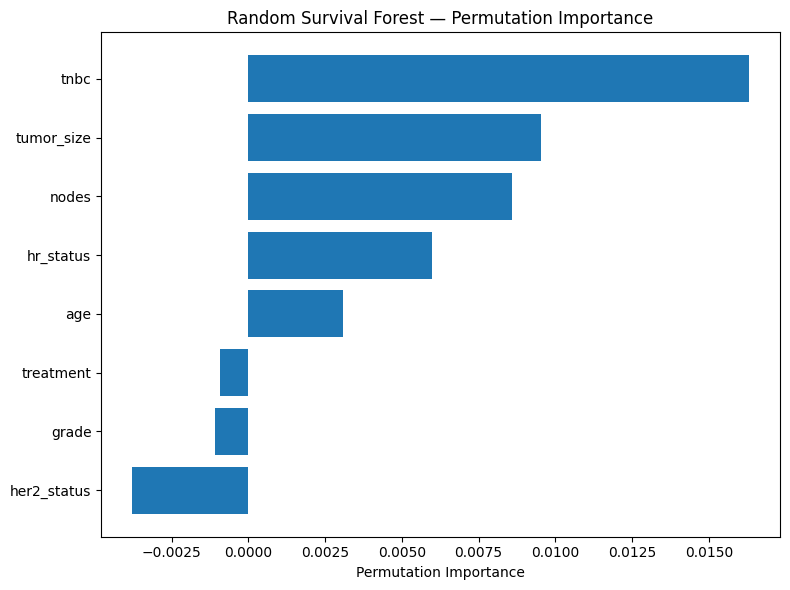

In [12]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Compute permutation importance using C-index scoring
result = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Random Survival Forest — Permutation Importance")
plt.tight_layout()

plt.savefig("rsf_variable_importance.png", dpi=300)
plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Create tertiles from test risk scores
risk_groups = pd.qcut(risk_scores, 3, labels=["Low Risk", "Intermediate Risk", "High Risk"])

# Build dataframe for plotting
df_test = pd.DataFrame({
    "time": y_test["time"],
    "event": y_test["event"],
    "risk_group": risk_groups
})

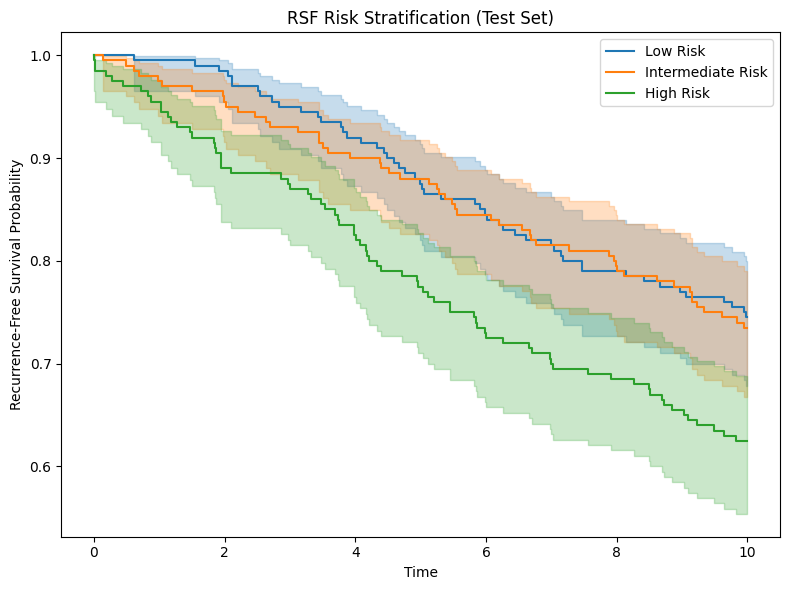

In [14]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in ["Low Risk", "Intermediate Risk", "High Risk"]:
    mask = df_test["risk_group"] == group
    kmf.fit(
        df_test[mask]["time"],
        df_test[mask]["event"],
        label=group
    )
    kmf.plot_survival_function()

plt.title("RSF Risk Stratification (Test Set)")
plt.xlabel("Time")
plt.ylabel("Recurrence-Free Survival Probability")
plt.tight_layout()

plt.savefig("rsf_risk_stratification.png", dpi=300)
plt.show()